# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [7]:
# Import the library
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

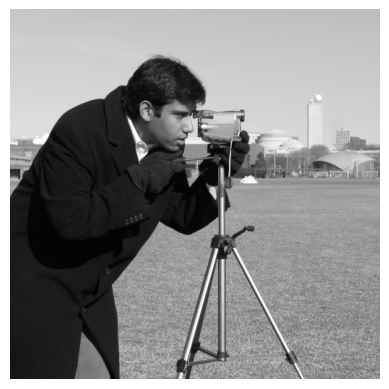

In [8]:
# ── Load image ────────────────────────────────────
image = data.camera()

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

Original size: (512, 512)
New size: (1024, 1024)


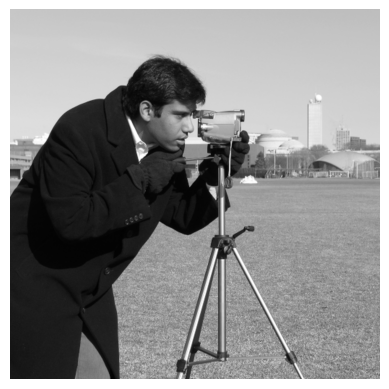

In [13]:
# Get the size of the image
width, height = image.size
scaled_image = image.resize(
    (width * 2, height * 2),
    Image.Resampling.LANCZOS
)
# scaling factors
scaled_image.save("task1_1_scaled.jpg")

print("Original size:", image.size)
print("New size:", scaled_image.size)

plt.imshow(scaled_image, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method



In [ ]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

Original size: (512, 512)
New size: (1024, 512)


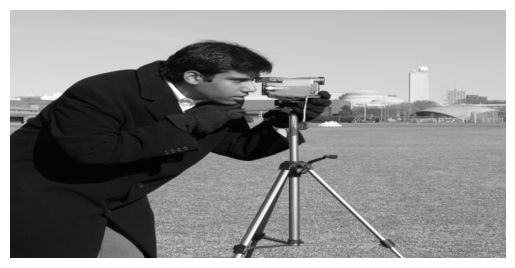

In [14]:
width, height = image.size

non_uniform = image.resize(
    (width * 2, height),
    Image.Resampling.LANCZOS
)

non_uniform.save("task1_1_nonuniform_scaled.jpg")

print("Original size:", image.size)
print("New size:", non_uniform.size)

plt.imshow(non_uniform, cmap="gray")
plt.axis("off")
plt.show()

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


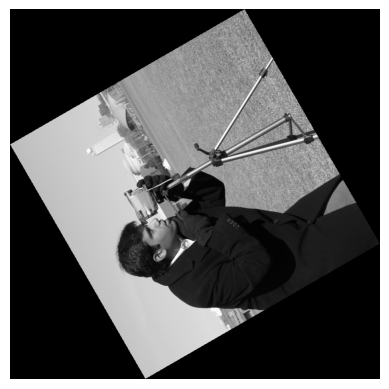

In [15]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image = image.rotate(
    120,
    expand=True,
    resample=Image.Resampling.BICUBIC
)

rotated_image.save("task1_2_rotated.jpg")

print("Original size:", image.size)
print("Rotated size:", rotated_image.size)

plt.imshow(rotated_image, cmap="gray")
plt.axis("off")
plt.show()


### 3. Shear

Original size: (512, 512)
Sheared size: (768, 512)


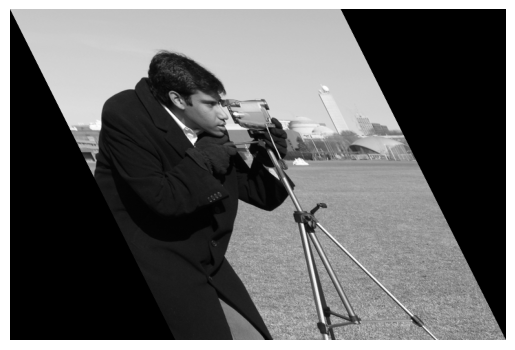

In [16]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size

shx = 0.5

new_width = int(width + abs(shx) * height)

sheared_image = image.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

sheared_image.save("task1_3_sheared.jpg")

print("Original size:", image.size)
print("Sheared size:", sheared_image.size)

plt.imshow(sheared_image, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.


In [ ]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]


In [ ]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

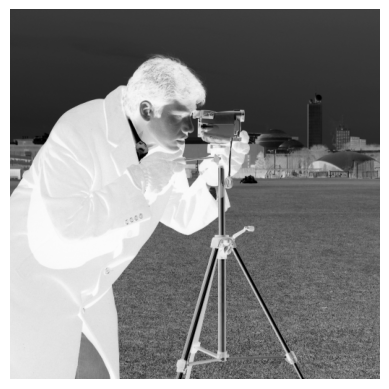

In [23]:

# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(image)

negative_arr = 255 - arr

negative_image = Image.fromarray(negative_arr.astype(np.uint8))

negative_image.save("negative_numpy.jpg")

plt.imshow(negative_image, cmap="gray")
plt.axis("off")
plt.show()

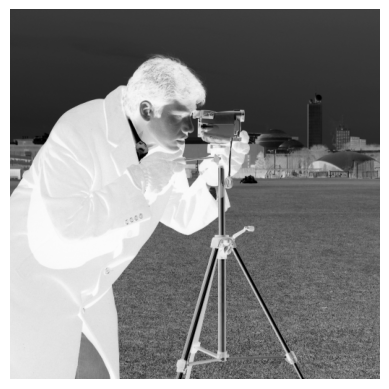

In [24]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(image)

negative_pil.save("negative_pil.jpg")

plt.imshow(negative_pil, cmap="gray")
plt.axis("off")
plt.show()

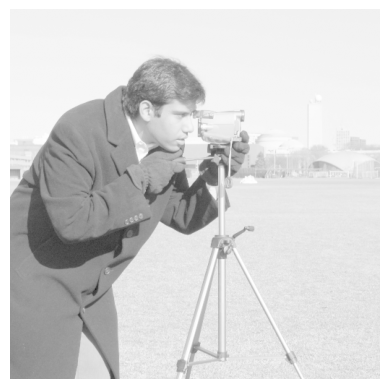

In [25]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
arr = np.array(image).astype(np.float32)

c = 255 / np.log(1 + 255)

log_transformed_arr = c * np.log(1 + arr)

log_transformed_arr = np.clip(log_transformed_arr, 0, 255)

log_transformed_image = Image.fromarray(
    log_transformed_arr.astype(np.uint8)
)

log_transformed_image.save("log_transformed.jpg")

plt.imshow(log_transformed_image, cmap="gray")
plt.axis("off")
plt.show()


# Apply the log transformation to each pixel


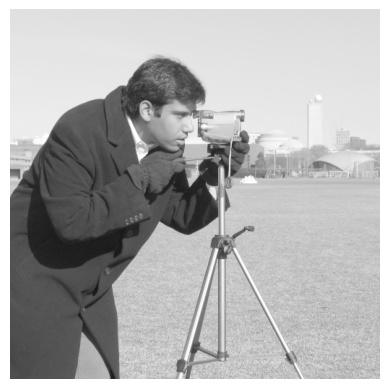

In [26]:

# ── 3. Power-law / Gamma correction ───────────────
arr = np.array(image).astype(np.float32)

gamma = 0.5

normalized_arr = arr / 255.0

gamma_transformed_arr = 255 * (normalized_arr ** gamma)

gamma_transformed_arr = np.clip(gamma_transformed_arr, 0, 255)

gamma_image = Image.fromarray(
    gamma_transformed_arr.astype(np.uint8)
)

gamma_image.save("power_law_gamma.jpg")

plt.imshow(gamma_image, cmap="gray")
plt.axis("off")
plt.show()